In [1]:
# Load libraries
import re, numpy as np, pandas as pd
from pathlib import Path
import random

# metrics
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Paths & hyperparams
DATA_PATH = "/content/FY23_Public Data_Low Value Care (1).xlsx"
TEST_SIZE = 0.2
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 30

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [2]:
# load
if DATA_PATH.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH)

df.columns = [c.strip() for c in df.columns]

def col(name):
    for c in df.columns:
        if c.lower() == name.lower():
            return c
    raise KeyError(f"Missing column: {name}")

region_col = col("Division of Insurance Region")
payer_col  = col("Payer Type")
year_col   = col("Year")
service_col= col("Service Type")
lv_spend   = col("Total LV Spending")
nec_spend  = col("Total Spending on Necessary Care")
volume_col = col("Total LV Services (Volume)")

# clean
def clean_money(s: pd.Series) -> pd.Series:
    x = s.astype(str).str.strip()
    x = x.replace({r"^\$-\s*$": np.nan, r"^\-$": np.nan, r"^\*$": np.nan, "": np.nan}, regex=True)
    x = x.apply(lambda v: re.sub(r"[^0-9\.\-]", "", v) if isinstance(v, str) else v)
    return pd.to_numeric(x, errors="coerce")

def clean_floatish(s: pd.Series) -> pd.Series:
    x = s.astype(str).str.strip()
    x = x.replace({r"^\*$": np.nan, r"^\-$": np.nan, "": np.nan}, regex=True)
    return pd.to_numeric(x, errors="coerce")

# cleaning
df[lv_spend]   = clean_money(df[lv_spend])
df[nec_spend]  = clean_money(df[nec_spend])
df[volume_col] = clean_floatish(df[volume_col])
df[year_col]   = pd.to_numeric(df[year_col], errors="coerce").astype("Int64")

# Drop rows
df = df.dropna(subset=[lv_spend, year_col]).reset_index(drop=True)
print("Rows after cleaning:", len(df))


Rows after cleaning: 11172


In [3]:
# Binary labels
y_cont = df[lv_spend].to_numpy()
median_spend = float(np.nanmedian(y_cont))
y = (y_cont >= median_spend).astype(np.int64)
print(f"Median threshold for High/Low LV Spending = ${median_spend:,.2f}")

# Features
cat_cols = [region_col, payer_col, service_col]
num_cols = [year_col, nec_spend, volume_col]
X = df[cat_cols + num_cols].copy()


Median threshold for High/Low LV Spending = $3,282.50


In [4]:
# Preprocess
preproc = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),  # sklearn >=1.2
        ]), cat_cols),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
    ],
    remainder="drop",
)

# Split
X_train_raw, X_test_raw, y_train_np, y_test_np = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Fit preprocessor on train
X_train_np = preproc.fit_transform(X_train_raw).astype("float32")
X_test_np  = preproc.transform(X_test_raw).astype("float32")

def check_finite(name, arr):
    arr = np.asarray(arr)
    print(f"{name}: shape={arr.shape}, NaN={np.isnan(arr).sum()}, Inf={np.isinf(arr).sum()}")

check_finite("X_train_np", X_train_np)
check_finite("X_test_np",  X_test_np)
check_finite("y_train_np", y_train_np)
check_finite("y_test_np",  y_test_np)

input_dim = X_train_np.shape[1]
print("Input dim:", input_dim)

# Tensors & loaders
X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_test  = torch.tensor(X_test_np,  dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)
y_test  = torch.tensor(y_test_np,  dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

# Class balance check
for name, arr in [("Train", y_train_np), ("Test", y_test_np)]:
    u, c = np.unique(arr, return_counts=True)
    print(f"{name} class counts:", dict(zip(u.tolist(), c.tolist())))


X_train_np: shape=(8937, 75), NaN=0, Inf=0
X_test_np: shape=(2235, 75), NaN=0, Inf=0
y_train_np: shape=(8937,), NaN=0, Inf=0
y_test_np: shape=(2235,), NaN=0, Inf=0
Input dim: 75
Train class counts: {0: 4468, 1: 4469}
Test class counts: {0: 1118, 1: 1117}


In [5]:
# Model: one hidden layer (>=3 units), one output
class OneHiddenBinaryMLP(nn.Module):
    def __init__(self, in_dim, hidden_units=16):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_units)
        self.act = nn.ReLU()
        self.out = nn.Linear(hidden_units, 1)

    def forward(self, x):
        x = self.act(self.fc1(x))
        return self.out(x)

model = OneHiddenBinaryMLP(input_dim, hidden_units=16).to(device)

# Handle imbalance
pos_weight = None
pos = (y_train_np == 1).sum()
neg = (y_train_np == 0).sum()
if pos > 0 and neg > 0:
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

print(model)
print("pos_weight:", None if pos_weight is None else float(pos_weight.cpu().numpy()))


OneHiddenBinaryMLP(
  (fc1): Linear(in_features=75, out_features=16, bias=True)
  (act): ReLU()
  (out): Linear(in_features=16, out_features=1, bias=True)
)
pos_weight: 0.9997762441635132


/tmp/ipython-input-3904019176.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("pos_weight:", None if pos_weight is None else float(pos_weight.cpu().numpy()))


In [6]:
import math
import matplotlib.pyplot as plt

hist = {"train_loss": [], "test_loss": [], "test_acc": []}

def epoch_accuracy(logits, y_true):
    #
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()
    correct = (preds == y_true).sum().item()
    return correct / y_true.numel()

def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()
    total_loss, total_n = 0.0, 0
    total_correct = 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            total_correct += epoch_accuracy(logits, yb) * xb.size(0)
            total_n += xb.size(0)
    return total_loss / total_n, total_correct / total_n

for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    te_loss, te_acc = run_epoch(test_loader,  train=False)
    hist["train_loss"].append(tr_loss)
    hist["test_loss"].append(te_loss)
    hist["test_acc"].append(te_acc)
    print(f"Epoch {ep:02d} | TrainLoss {tr_loss:.4f} | TestLoss {te_loss:.4f} | TestAcc {te_acc:.3f}")


Epoch 01 | TrainLoss 0.6588 | TestLoss 0.5959 | TestAcc 0.782
Epoch 02 | TrainLoss 0.5142 | TestLoss 0.4547 | TestAcc 0.825
Epoch 03 | TrainLoss 0.4142 | TestLoss 0.4010 | TestAcc 0.833
Epoch 04 | TrainLoss 0.3770 | TestLoss 0.3801 | TestAcc 0.838
Epoch 05 | TrainLoss 0.3615 | TestLoss 0.3710 | TestAcc 0.837
Epoch 06 | TrainLoss 0.3533 | TestLoss 0.3649 | TestAcc 0.841
Epoch 07 | TrainLoss 0.3474 | TestLoss 0.3607 | TestAcc 0.843
Epoch 08 | TrainLoss 0.3427 | TestLoss 0.3568 | TestAcc 0.845
Epoch 09 | TrainLoss 0.3388 | TestLoss 0.3537 | TestAcc 0.845
Epoch 10 | TrainLoss 0.3353 | TestLoss 0.3509 | TestAcc 0.847
Epoch 11 | TrainLoss 0.3316 | TestLoss 0.3467 | TestAcc 0.851
Epoch 12 | TrainLoss 0.3283 | TestLoss 0.3441 | TestAcc 0.851
Epoch 13 | TrainLoss 0.3248 | TestLoss 0.3412 | TestAcc 0.855
Epoch 14 | TrainLoss 0.3214 | TestLoss 0.3384 | TestAcc 0.855
Epoch 15 | TrainLoss 0.3184 | TestLoss 0.3354 | TestAcc 0.855
Epoch 16 | TrainLoss 0.3150 | TestLoss 0.3329 | TestAcc 0.856
Epoch 17

Test Accuracy: 0.871
Confusion matrix [[TN, FP], [FN, TP]]:
 [[990 128]
 [161 956]]


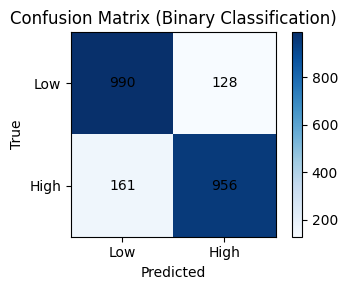

In [7]:
# Collect predictions on the test set
model.eval()
all_probs, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        all_probs.append(probs)
        all_true.append(yb.numpy().ravel())

probs = np.concatenate(all_probs)
y_true = np.concatenate(all_true).astype(int)
y_pred = (probs >= 0.5).astype(int)

acc = accuracy_score(y_true, y_pred)
cm  = confusion_matrix(y_true, y_pred, labels=[0,1])
print(f"Test Accuracy: {acc:.3f}")
print("Confusion matrix [[TN, FP], [FN, TP]]:\n", cm)

# Inline heatmap
fig, ax = plt.subplots(figsize=(4,3))
im = ax.imshow(cm, cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix (Binary Classification)")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Low","High"]); ax.set_yticklabels(["Low","High"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for (i,j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center")
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()


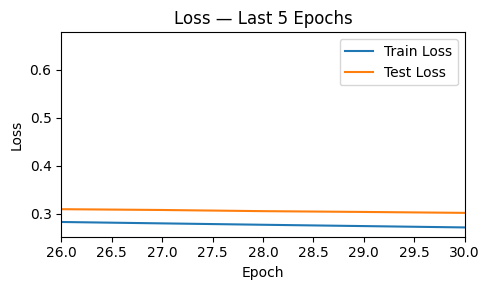

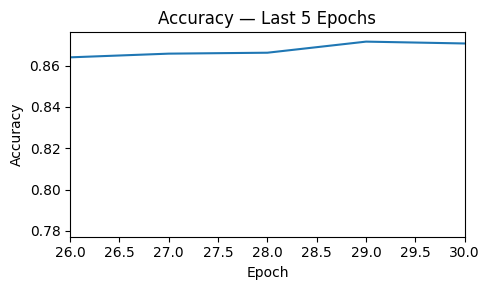

In [8]:
# Loss — last 5 epochs
plt.figure(figsize=(5,3))
plt.plot(range(1, EPOCHS+1), hist["train_loss"], label="Train Loss")
plt.plot(range(1, EPOCHS+1), hist["test_loss"],  label="Test Loss")
plt.xlim(max(1, EPOCHS-4), EPOCHS)
plt.title("Loss — Last 5 Epochs")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.tight_layout(); plt.show()

# Accuracy — last 5 epochs
plt.figure(figsize=(5,3))
plt.plot(range(1, EPOCHS+1), hist["test_acc"], label="Test Accuracy")
plt.xlim(max(1, EPOCHS-4), EPOCHS)
plt.title("Accuracy — Last 5 Epochs")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.tight_layout(); plt.show()


Task: Binary classification of High vs Low Total LV Spending (median threshold = $X).

Architecture: One hidden layer (16 units), ReLU activation; one output neuron (logit); loss = BCEWithLogitsLoss; optimizer = Adam, lr = 1e-3; epochs = 30; batch size = 64.

Data split: 80/20 train/test, stratified, disjoint.

Results to include: Test accuracy, confusion matrix image, and last 5 epochs plots (loss & accuracy).

Reproducibility: random seeds set


In [10]:
# Inline sample
sample_cols = [region_col, payer_col, year_col, service_col, lv_spend, nec_spend, volume_col]
df[sample_cols].head(12)


,Division of Insurance Region,Payer Type,Year,Service Type,Total LV Spending,Total Spending on Necessary Care,Total LV Services (Volume)
0,Boulder,CHP+,2017,25-OH-Vitamin D Deficiency,329,246,NaN
1,Boulder,CHP+,2017,Annual Resting EKGs,0,12771,0.0
2,Boulder,CHP+,2017,Antibiotics for Acute Upper Respiratory and Ea...,714,0,28.0
3,Boulder,CHP+,2017,Antibiotics for Adenoviral Conjunctivitis,18,0,NaN
4,Boulder,CHP+,2017,Cardiac Stress Testing,0,1451,0.0
5,Boulder,CHP+,2017,Cervical Cancer Screening for Women,0,2608,0.0
6,Boulder,CHP+,2017,Cough and Cold Medicines in Children < 4 Years,33,0,NaN
7,Boulder,CHP+,2017,CT Scans for Abdominal Pain in Children,2098,35830,NaN
8,Boulder,CHP+,2017,Dexa,0,10,0.0
9,Boulder,CHP+,2017,Headache Image,375,0,NaN


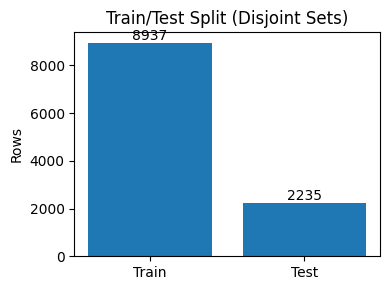

In [11]:
# Inline train/test split image
import matplotlib.pyplot as plt
n_train, n_test = len(X_train), len(X_test)
fig, ax = plt.subplots(figsize=(4,3))
ax.bar(["Train","Test"], [n_train, n_test])
ax.set_title("Train/Test Split (Disjoint Sets)")
ax.set_ylabel("Rows")
for i, v in enumerate([n_train, n_test]):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout(); plt.show()


In [13]:
sample_df = df[sample_cols].head(12)
sample_df.to_csv("sample_low_value_care_rows.csv", index=False)
print("sample_low_value_care_rows.csv")


sample_low_value_care_rows.csv
